In [2]:
import numpy as np 
import pandas as pd


import matplotlib.pyplot as plt 
import seaborn as sns 
from scipy import stats 
from scipy.stats import skew, norm 

from sklearn.linear_model import LinearRegression, Ridge,Lasso,ElasticNet,RidgeCV,LassoCV,ElasticNetCV
from sklearn.ensemble import RandomForestRegressor,GradientBoostingClassifier,StackingRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV,RandomizedSearchCV, train_test_split


import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,5)
pd.set_option ("display.max_columns",100)

RANDOM_STATE= 42
np.random.seed(RANDOM_STATE)

In [3]:
train =pd.read_csv("train.csv")
test =pd.read_csv("test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()


Train shape: (1460, 81)
Test shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
if "Id" in train.columns:
    train_Id = train.pop("Id")

if "Id" in test.columns:
    test_ID = test.pop ("Id")
    

Exploratory Data Analysis 

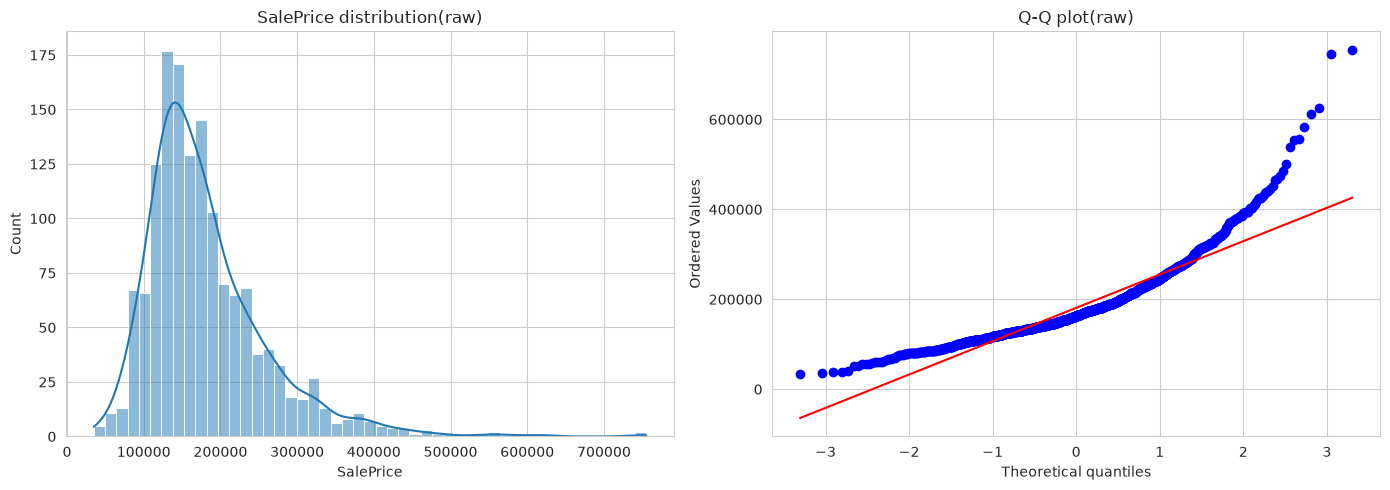

Skewness:1.883
kurtosis:6.536


In [5]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.histplot(train["SalePrice"], kde = True, ax = axes[0])
axes[0].set_title("SalePrice distribution(raw)")

stats.probplot(train["SalePrice"], plot= axes[1])
axes[1].set_title("Q-Q plot(raw)")
plt.tight_layout()
plt.show()

print("Skewness:%.3f"%train["SalePrice"].skew())
print("kurtosis:%.3f"%train["SalePrice" ].kurt())

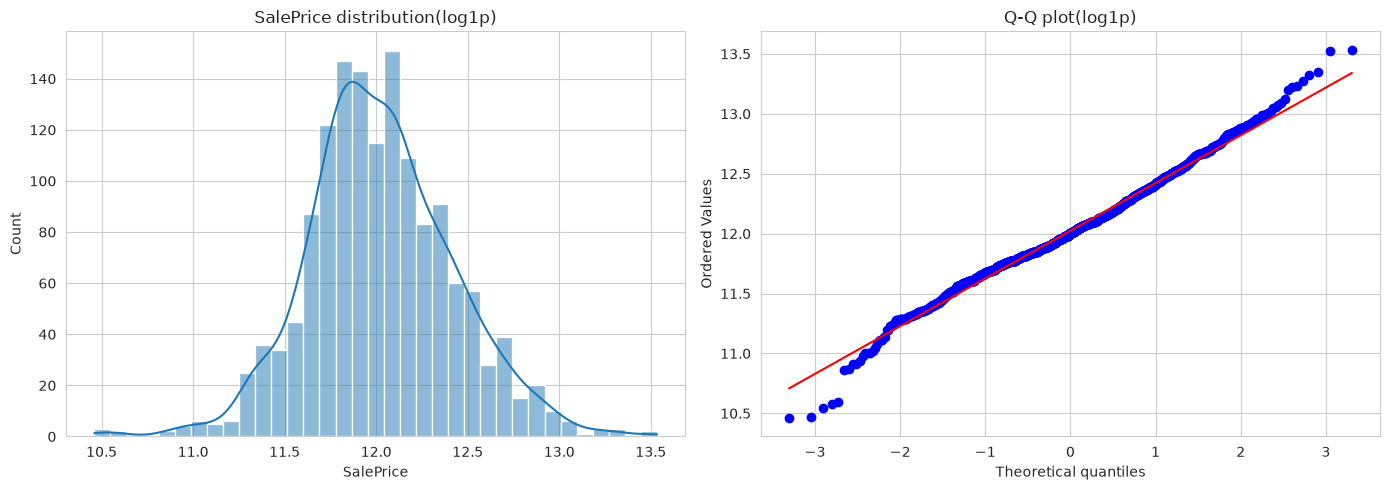

Skewness:0.121


In [6]:
train["SalePrice"] = np.log1p(train["SalePrice"])
fig,axes = plt.subplots(1,2, figsize=(14,5))
sns.histplot(train["SalePrice"], kde = True, ax = axes[0])
axes[0].set_title("SalePrice distribution(log1p)")

stats.probplot(train["SalePrice"], plot= axes[1])
axes[1].set_title("Q-Q plot(log1p)")
plt.tight_layout()
plt.show()

print("Skewness:%.3f"%train["SalePrice"].skew())


Missing data 

In [7]:
def missing_table(df):
    total = df.isnull().sum()
    pct = 100 * total / len(df)
    tbl = pd.concat([total, pct], axis=1, keys=['Total', 'Percent'])
    return tbl[tbl['Total'] > 0].sort_values('Percent', ascending=False)

miss_train = missing_table(train.drop(columns=['SalePrice', 'SalePrice_log'], errors='ignore'))
miss_train

,Total,Percent
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


In [8]:
train['SalePrice_log'] = np.log1p(train['SalePrice'])
assert 'SalePrice_log' in train.columns
print('OK, SalePrice_log created')

OK, SalePrice_log created


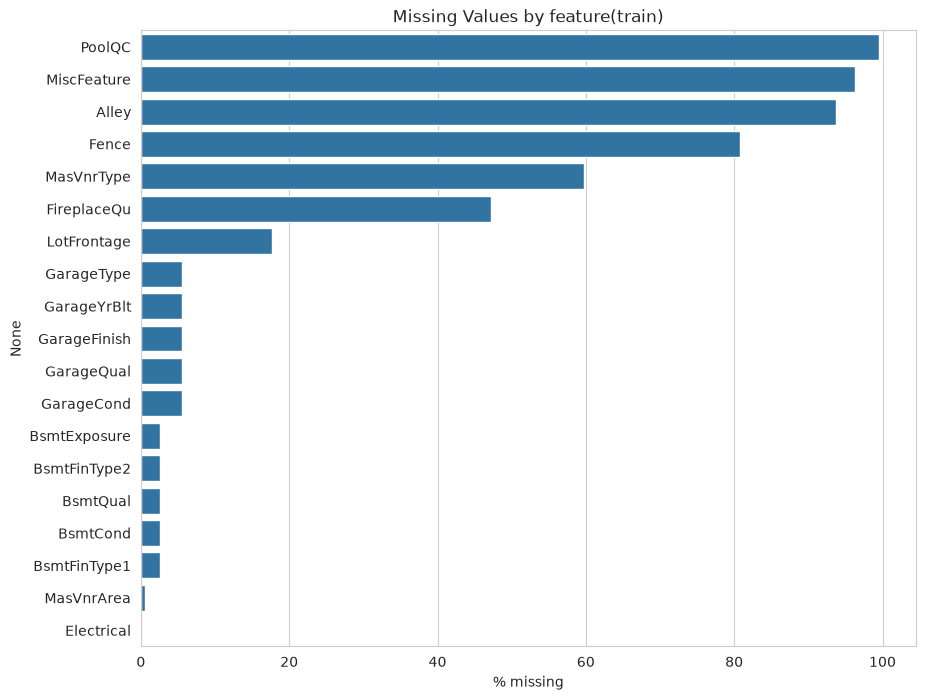

In [9]:
plt.figure(figsize=(10,8))
sns.barplot(x=miss_train["Percent"],y=miss_train.index)
plt.title("Missing Values by feature(train)")
plt.xlabel("% missing")
plt.show()


Numerical feature distribution and relationship to price

In [10]:


num_features = train.select_dtypes(include=[np.number]).columns.drop(['SalePrice', 'SalePrice_log'])
print(f'{len(num_features)} numerical features')

corr = train[list(num_features) + ['SalePrice']].corr()['SalePrice'].sort_values(ascending=False)
corr.drop('SalePrice').head(15)




36 numerical features


OverallQual     0.817185
GrLivArea       0.700927
GarageCars      0.680625
GarageArea      0.650888
TotalBsmtSF     0.612134
1stFlrSF        0.596981
FullBath        0.594771
YearBuilt       0.586570
YearRemodAdd    0.565608
GarageYrBlt     0.541073
TotRmsAbvGrd    0.534422
Fireplaces      0.489450
MasVnrArea      0.430809
BsmtFinSF1      0.372023
LotFrontage     0.355879
Name: SalePrice, dtype: float64

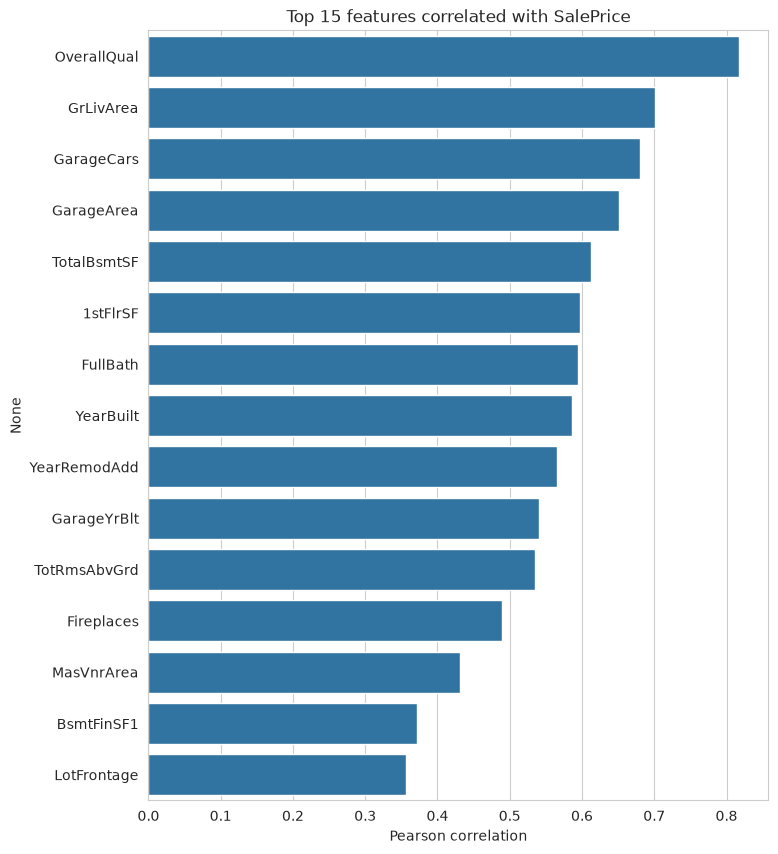

In [11]:
plt.figure(figsize=(8,10))
top_corr = corr.drop("SalePrice").head(15)
sns.barplot(x=top_corr.values,y=top_corr.index)
plt.title("Top 15 features correlated with SalePrice")
plt.xlabel("Pearson correlation")
plt.show()


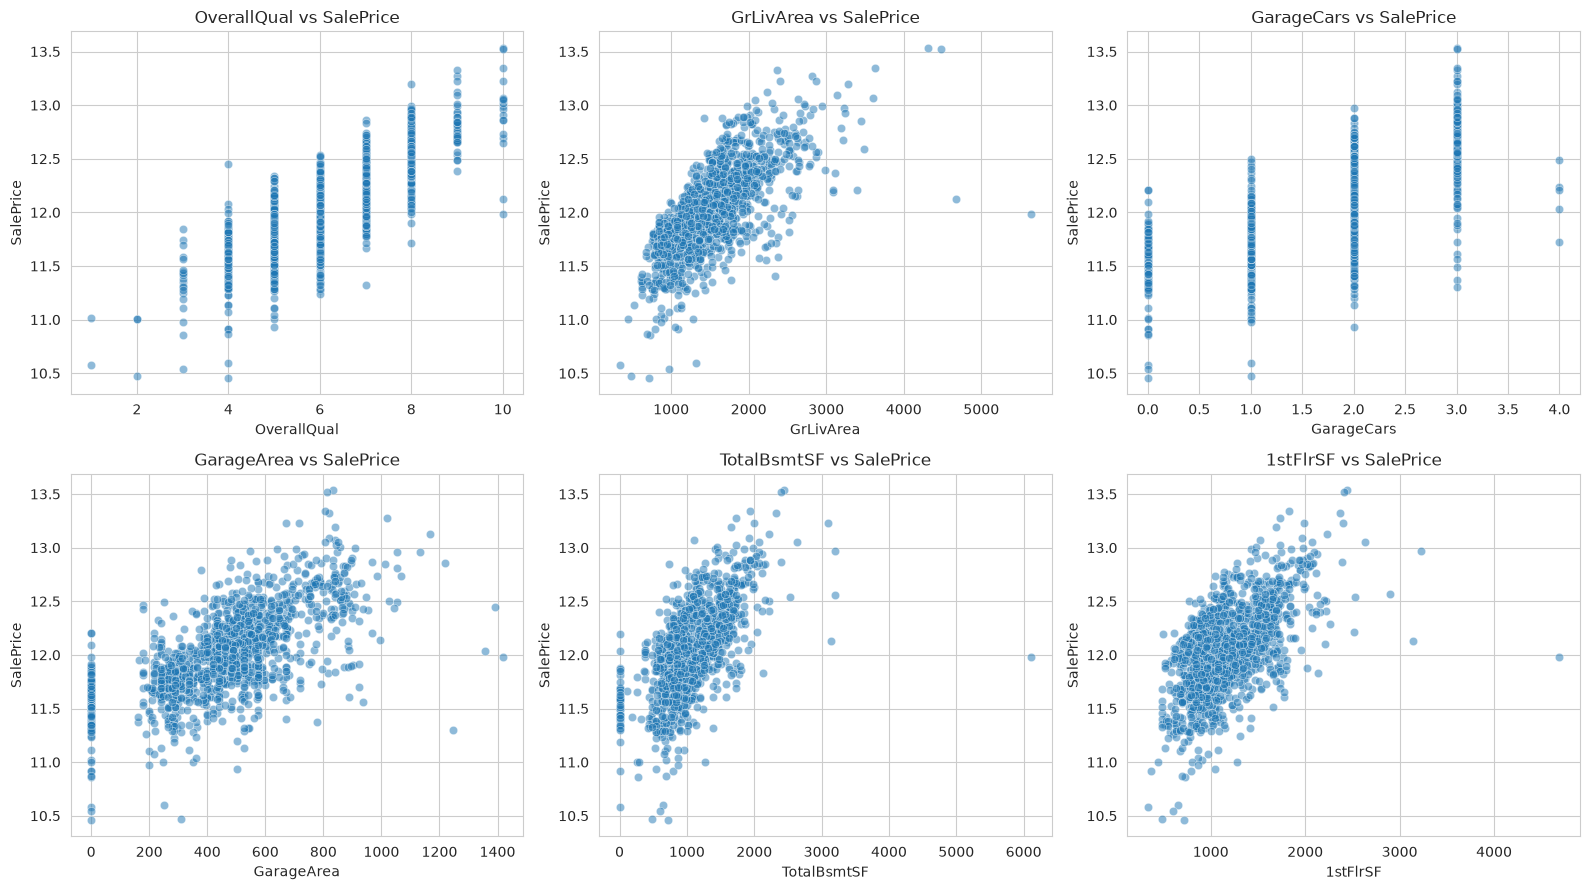

In [12]:
top_feats =["OverallQual", "GrLivArea", "GarageCars", "GarageArea", "TotalBsmtSF", "1stFlrSF", "FullBath", "TotRmsAbvGrd", "YearBuilt", "YearRemodAdd"]
fig, axes = plt.subplots(2,3,figsize=(16,9))
for ax, feat in zip(axes.flat,top_feats):
    sns.scatterplot(x=train[feat],y=train["SalePrice"],ax=ax,alpha=0.5)
    ax.set_title(f"{feat} vs SalePrice")
plt.tight_layout()
plt.show()


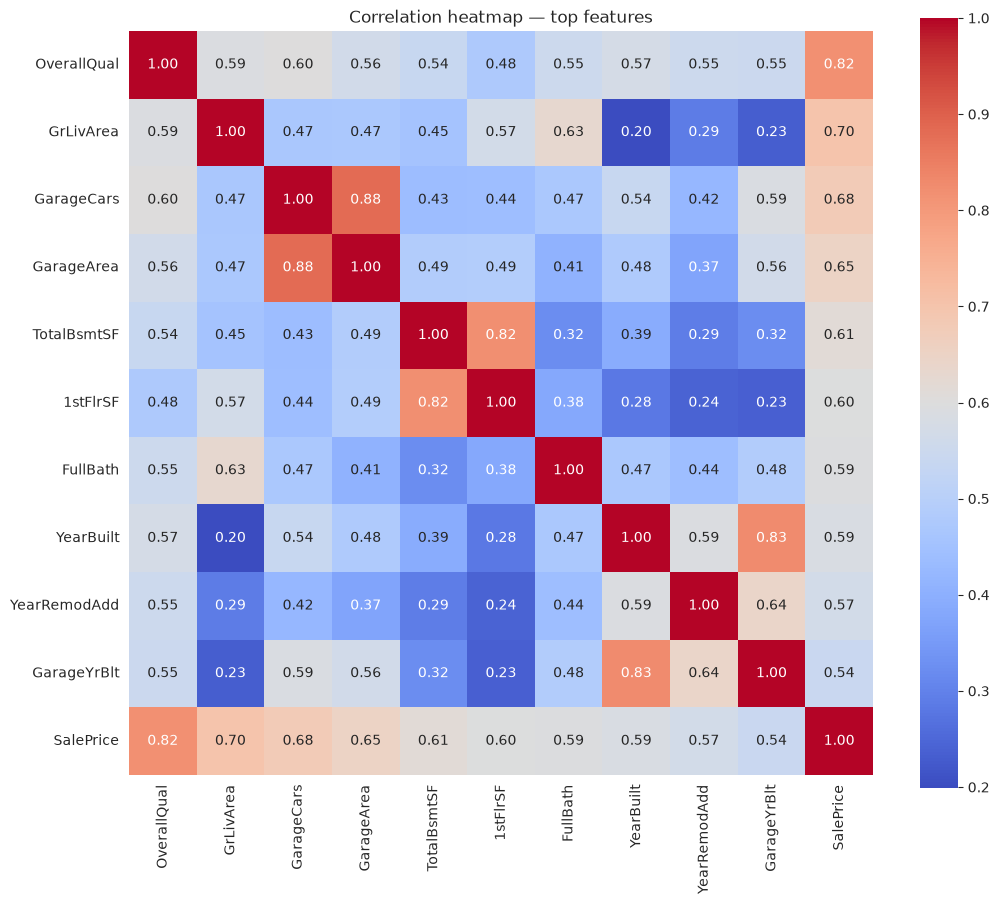

In [13]:
plt.figure(figsize=(12, 10))
top_corr_matrix = train[corr.drop('SalePrice').head(10).index.tolist() + ['SalePrice']].corr()
sns.heatmap(top_corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation heatmap — top features')
plt.show()



Categorical Features

43 categorical features


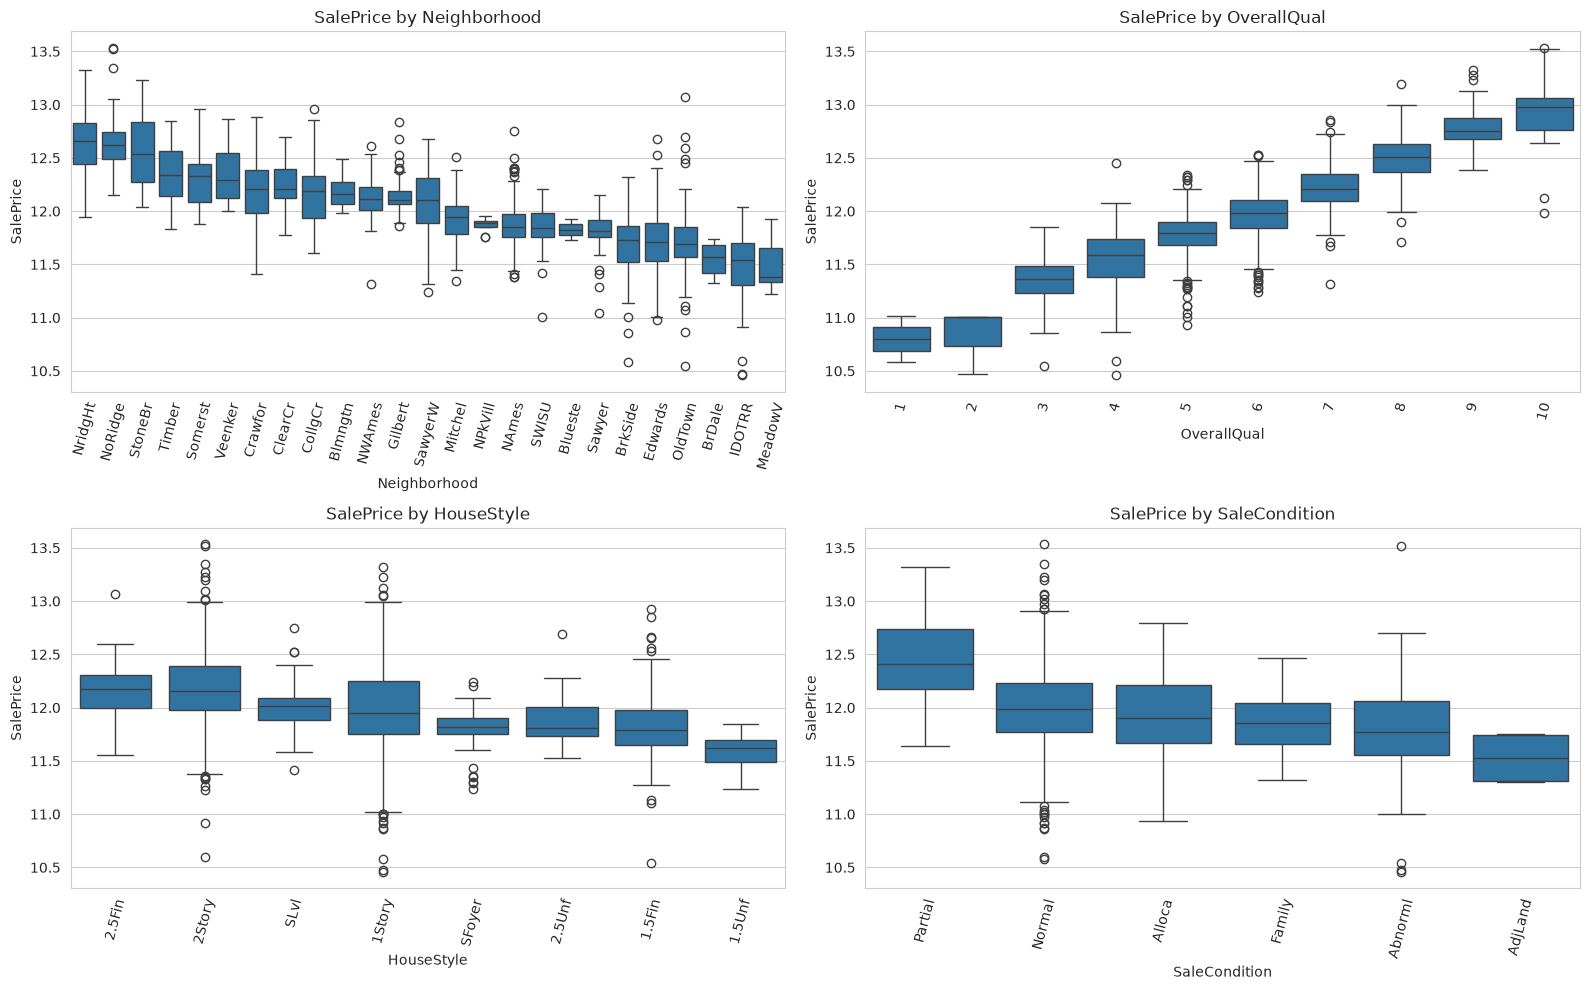

In [14]:


cat_features = train.select_dtypes(exclude=[np.number]).columns
print(f'{len(cat_features)} categorical features')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, feat in zip(axes.flat, ['Neighborhood', 'OverallQual', 'HouseStyle', 'SaleCondition']):
    if feat == 'OverallQual':
        order = sorted(train[feat].unique())
    else:
        order = train.groupby(feat)['SalePrice'].median().sort_values(ascending=False).index
    sns.boxplot(x=feat, y='SalePrice', data=train, order=order, ax=ax)
    ax.set_title(f'SalePrice by {feat}')
    ax.tick_params(axis='x', rotation=75)
plt.tight_layout()
plt.show()


    

Data Cleaning


In [16]:
train = train.drop(train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)].index)
train.reset_index(drop=True, inplace=True)
print('Train shape after outlier removal:', train.shape)

Train shape after outlier removal: (1456, 81)


In [18]:


ntrain = train.shape[0]
ntest = test.shape[0]
y_train = train['SalePrice_log'].values

all_data = pd.concat([train.drop(['SalePrice', 'SalePrice_log'], axis=1), test]).reset_index(drop=True)
print('Combined shape:', all_data.shape)



Combined shape: (2915, 79)


In [19]:
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']

for col in none_cols:
    all_data[col] = all_data[col].fillna('None')




Missing Values 

In [21]:
zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
             'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']

for col in zero_cols:
    all_data[col] = all_data[col].fillna(0)



In [23]:

all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)


all_data['MSZoning'] = all_data.groupby('MSSubClass')['MSZoning'].transform(
    lambda x: x.fillna(x.mode()[0])
)


all_data['Functional'] = all_data['Functional'].fillna('Typ')

mode_cols = ['Electrical', 'KitchenQual', 'Exterior1st', 'Exterior2nd', 'SaleType']
for col in mode_cols:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

all_data = all_data.drop(['Utilities'], axis=1)



In [24]:
remaining_missing = all_data.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
print('Columns still missing values:', list(remaining_missing.index))
assert remaining_missing.empty, 'There are still missing values!'

Columns still missing values: []


Feature Engineering

In [25]:
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']

all_data['TotalBathrooms'] = (all_data['FullBath'] + 0.5 * all_data['HalfBath'] +
                               all_data['BsmtFullBath'] + 0.5 * all_data['BsmtHalfBath'])

all_data['HouseAge'] = all_data['YrSold'] - all_data['YearBuilt']
all_data['RemodAge'] = all_data['YrSold'] - all_data['YearRemodAdd']
all_data['IsRemodeled'] = (all_data['YearBuilt'] != all_data['YearRemodAdd']).astype(int)
all_data['GarageAge'] = all_data['YrSold'] - all_data['GarageYrBlt']
all_data.loc[all_data['GarageYrBlt'] == 0, 'GarageAge'] = 0  # no garage

all_data['HasPool'] = (all_data['PoolArea'] > 0).astype(int)
all_data['Has2ndFloor'] = (all_data['2ndFlrSF'] > 0).astype(int)
all_data['HasGarage'] = (all_data['GarageArea'] > 0).astype(int)
all_data['HasBsmt'] = (all_data['TotalBsmtSF'] > 0).astype(int)
all_data['HasFireplace'] = (all_data['Fireplaces'] > 0).astype(int)

print('New feature count check — shape:', all_data.shape)

New feature count check — shape: (2915, 89)


Ordinal encoding for quality/condition features

In [26]:
qual_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
             'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']
for col in qual_cols:
    all_data[col] = all_data[col].map(qual_map)

bsmt_exposure_map = {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
all_data['BsmtExposure'] = all_data['BsmtExposure'].map(bsmt_exposure_map)

bsmt_fin_map = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
all_data['BsmtFinType1'] = all_data['BsmtFinType1'].map(bsmt_fin_map)
all_data['BsmtFinType2'] = all_data['BsmtFinType2'].map(bsmt_fin_map)

garage_finish_map = {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}
all_data['GarageFinish'] = all_data['GarageFinish'].map(garage_finish_map)

functional_map = {'Sal': 0, 'Sev': 1, 'Maj2': 2, 'Maj1': 3, 'Mod': 4,
                   'Min2': 5, 'Min1': 6, 'Typ': 7}
all_data['Functional'] = all_data['Functional'].map(functional_map)



In [27]:
all_data['MSSubClass'] = all_data['MSSubClass'].astype(str)
all_data['MoSold'] = all_data['MoSold'].astype(str)

Fix skewed numeric features

In [29]:
from scipy.special import boxcox1p

numeric_feats = all_data.select_dtypes(include=[np.number]).columns
skewed_feats = all_data[numeric_feats].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
skewness = skewed_feats[abs(skewed_feats) > 0.75]
print(f'{len(skewness)} skewed numeric features to transform')
skewness.head(10)

34 skewed numeric features to transform


MiscVal          21.932147
PoolQC           20.921993
PoolArea         18.701829
HasPool          16.186531
LotArea          13.123758
LowQualFinSF     12.080315
3SsnPorch        11.368094
KitchenAbvGr      4.298845
BsmtFinSF2        4.142863
EnclosedPorch     4.000796
dtype: float64

In [30]:
lam = 0.15
for feat in skewness.index:
    all_data[feat] = boxcox1p(all_data[feat], lam)

One-hot encode remaining (nominal) categorical features

In [31]:
all_data = pd.get_dummies(all_data, drop_first=True)
print('Final feature matrix shape:', all_data.shape)

Final feature matrix shape: (2915, 242)


In [32]:
X_train = all_data[:ntrain]
X_test = all_data[ntrain:]

print('X_train:', X_train.shape, ' y_train:', y_train.shape)
print('X_test :', X_test.shape)

X_train: (1456, 242)  y_train: (1456,)
X_test : (1459, 242)


 Modeling
 